<a href="https://colab.research.google.com/github/nterreri-cmu/p2-datacenters/blob/compiled_analysis/Python_Data_Centers_Nguyen_Terreri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Centers and Energy Use: An Exploratory Data Analysis
by Vi Nguyen and Natali Terreri
Python Programming II, Fall 2026

In [ ]:
# import Pandas
import pandas as pd

# import numpy
import numpy as np

#matplot
import matplotlib.pyplot as plt

#seaborn
import seaborn as sns



In [ ]:
#upload data center data file

dc_url = 'https://raw.githubusercontent.com/nterreri-cmu/p2-datacenters/refs/heads/main/datacenters_clean.csv'

datacenters_df = pd.read_csv(dc_url)


In [ ]:
display(datacenters_df)

,facility_name,address,city,state,zip,county,lat,lon,status,location_confidence,operator_name,mw,sizerank,facility_size_sqft,property_size_acres,community_pushback,information_source,date_created,date_updated,status_group
0,Stak Energy Data Center,"Dalton Hwy, 26 miles south of Deadhorse",North Slope Borough,AK,99734.0,North Slope,69.900710,-148.81477,Proposed,Medium,Stak,3000,"Mega campus (>1,000 MW)",NaN,715.0,Unknown,Media Monitoring,5/20/2026,7/8/2026,planned
1,Prudhoe Bay Data Center,Dalton Hwy,Prudhoe Bay,AK,99734.0,North Slope,70.184780,-148.44000,Operating,Medium,"Far North Digital, LLC",120,Hyperscale (100-999 MW),NaN,100.0,Unknown,Media Monitoring,5/20/2026,5/20/2026,operating
2,Project Marvel,Red Ridge on Rock Mountain Lake Rd and Old Law...,Bessemer,AL,35022.0,Jefferson,33.342000,-87.03410,Proposed,High,Logistic Land Investments LLC,1200,"Mega campus (>1,000 MW)","4,500,000",1600.0,Yes,Media Monitoring,9/16/2025,7/8/2026,planned
3,BHM01 Nebius Data Center,201 Milan Parkway,Birmingham,AL,35221.0,Jefferson,33.427460,-86.88143,Proposed,High,"Nebius, Alabama ADC Holdings LLC",300,Hyperscale (100-999 MW),NaN,80.0,Unknown,Media Monitoring,2/20/2026,7/8/2026,planned
4,DC Blox,433 6th St S,Birmingham,AL,35233.0,Jefferson,33.500510,-86.82100,Operating,High,NaN,NaN,NaN,NaN,NaN,Unknown,Media Monitoring,8/25/2025,8/25/2025,operating
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,Microsoft Azure Data Center,644 Logistics Dr,Cheyenne,WY,82009.0,Laramie,41.123720,-104.90100,Approved/Permitted/Under construction,High,Microsoft,NaN,NaN,NaN,NaN,Unknown,Media Monitoring,8/11/2025,8/11/2025,planned
1696,Microsoft Cheyenne Data Center,Near Wapiti Trail,Cheyenne,WY,82007.0,Laramie,41.064470,-104.77278,Proposed,Medium,Microsoft,NaN,Hyperscale (100-999 MW),NaN,3200.0,Unknown,Media Monitoring,4/15/2026,4/15/2026,planned
1697,Project Tembo/ now Project Braid,"Switchgrass Industrial Park, west of I-85. 2 m...",Cheyenne,WY,82007.0,Laramie,41.031693,-104.79640,Suspended,High,Google,"10,000","Mega campus (>1,000 MW)",NaN,1375.0,Yes,Crowdsourced,12/8/2025,9/10/2026,stalled
1698,Related Digital Cheyenne Data Center,"Cheyenne Business Parkway, Campstool Rd, north...",Cheyenne,WY,82007.0,Laramie,41.137573,-104.71874,Proposed,Medium,Related Digital/CoreWeave,250,Hyperscale (100-999 MW),NaN,113.0,Unknown,Crowdsourced,12/8/2025,12/8/2025,planned


In [ ]:
#review dataframe details
datacenters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   facility_name        1700 non-null   object 
 1   address              1655 non-null   object 
 2   city                 1696 non-null   object 
 3   state                1700 non-null   object 
 4   zip                  1688 non-null   float64
 5   county               1697 non-null   object 
 6   lat                  1700 non-null   float64
 7   lon                  1700 non-null   float64
 8   status               1700 non-null   object 
 9   location_confidence  1698 non-null   object 
 10  operator_name        1007 non-null   object 
 11  mw                   676 non-null    object 
 12  sizerank             814 non-null    object 
 13  facility_size_sqft   1029 non-null   object 
 14  property_size_acres  1018 non-null   float64
 15  community_pushback   1700 non-null   o

# 2. Data Centers EDA

Explore data center distribution by State and status to gain understanding of how the pressure of data centers differ across the United States.

In [ ]:
#create a new dataframe of states with aggregated numbers for planned vs active sites.

datacenters_states_df = (
    datacenters_df
    .pivot_table(index='state', columns='status_group',
                 aggfunc='size', fill_value=0)
    [['planned', 'operating']]
    .reset_index()
)
datacenters_states_df['all_sites'] = datacenters_states_df['planned'] + datacenters_states_df['operating']

In [ ]:
#View summary statistical data for data centers across states.
datacenters_states_df.describe()

status_group,planned,operating,all_sites
count,48.000000,48.000000,48.000000
mean,19.729167,12.562500,32.291667
std,39.574191,34.185916,73.135537
min,0.000000,0.000000,1.000000
25%,3.000000,1.000000,6.750000
50%,8.000000,4.000000,12.000000
75%,16.000000,6.250000,22.500000
max,235.000000,214.000000,449.000000


U.S. States have an average of 12 operating data centers and 20 data centers planning to be build. There is a wide distribution across states with some states having no active data centers and the top state (Virginia) having 214 currently operating. There are only 48 states present in the data set meaning that based on this data, two States have no operating or planned data centers. The box plot below shows a strong right skew to the number of data centers per state.

Text(0.5, 0, 'Number of Data Centers')

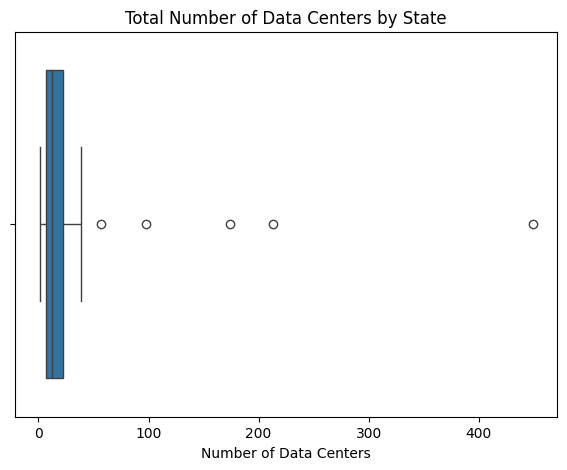

In [ ]:
#Boxplot of number of data centers by state
fig, ax = plt.subplots(figsize = (7,5))
sns.boxplot(data=datacenters_states_df, x="all_sites", ax=ax)
ax.set_title("Total Number of Data Centers by State")
ax.set_xlabel('Number of Data Centers')

Based on the distribution of total planned and operating datacenters by state, we will focus our exploration on the top 6 states by number of datacenters, all of which are outliers.

In [ ]:
#Top 6 States
print(datacenters_states_df.sort_values('all_sites', ascending = False).head(6))

status_group state  planned  operating  all_sites
43              VA      235        214        449
41              TX      138         75        213
9               GA       87         87        174
37              PA       56         42         98
34              OH       37         20         57
4               CA       30          9         39


In [ ]:
top_states = ['VA','TX','GA','PA','OH','CA']

In [ ]:
#Bottom 6 States
print(datacenters_states_df.sort_values('all_sites', ascending = True).head(6))

status_group state  planned  operating  all_sites
10              HI        0          1          1
29              NH        0          1          1
7               DE        2          0          2
0               AK        1          1          2
39              SD        2          0          2
12              ID        3          0          3


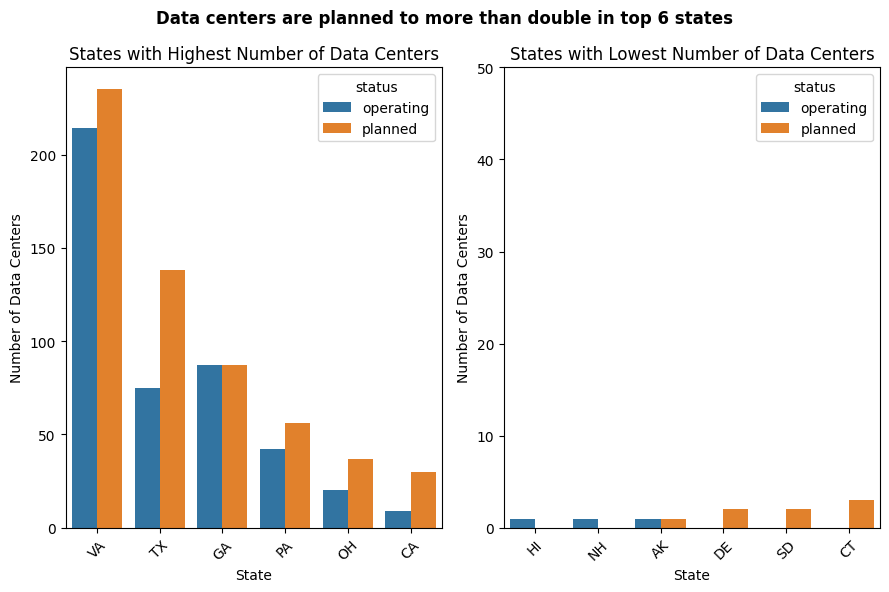

In [ ]:
# Filters for top 6 and bottom 6 states by total sites
top_6 = datacenters_states_df.nlargest(6, 'all_sites')
bottom_6 = datacenters_states_df.nsmallest(6, 'all_sites')

# Translate two columns into rows
def to_long(df):
    return df.melt(
        id_vars='state',
        value_vars=['operating', 'planned'],
        var_name='status',
        value_name='sites'
    )

#Create side by side barplots
fig, axes = plt.subplots(1,2, figsize=(9, 6))
plt.suptitle("Data centers are planned to more than double in top 6 states", fontsize = 12, fontweight = "bold" )

for ax, subset, title in zip(
    axes,
    [top_6, bottom_6],
    ['States with Highest Number of Data Centers', 'States with Lowest Number of Data Centers'],

):
    sns.barplot(
        data=to_long(subset),
        x='state', y='sites', hue='status',
        order=subset['state'],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('State')
    ax.set_ylabel('Number of Data Centers')
    ax.tick_params(axis='x', rotation=45)
    axes[1].set_ylim(0, 50)


plt.tight_layout()
plt.show()

Size Rank

In [ ]:
print(datacenters_df['sizerank'].value_counts())

sizerank
Hyperscale (100-999 MW)    395
Medium (11-50 MW)          139
Mega campus (>1,000 MW)    123
Small (0-10 MW)            116
Large (51-99 MW)            41
Name: count, dtype: int64


In [ ]:
size_order = ['Small (0-10 MW)', 'Medium (11-50 MW)', 'Large (51-99 MW)', 'Hyperscale (100-999 MW)', 'Mega campus (>1,000 MW)']
datacenters_df['sizerank'] = pd.Categorical(datacenters_df['sizerank'], categories=size_order, ordered=True)

print(datacenters_df['sizerank'].value_counts())

sizerank
Hyperscale (100-999 MW)    395
Medium (11-50 MW)          139
Mega campus (>1,000 MW)    123
Small (0-10 MW)            116
Large (51-99 MW)            41
Name: count, dtype: int64


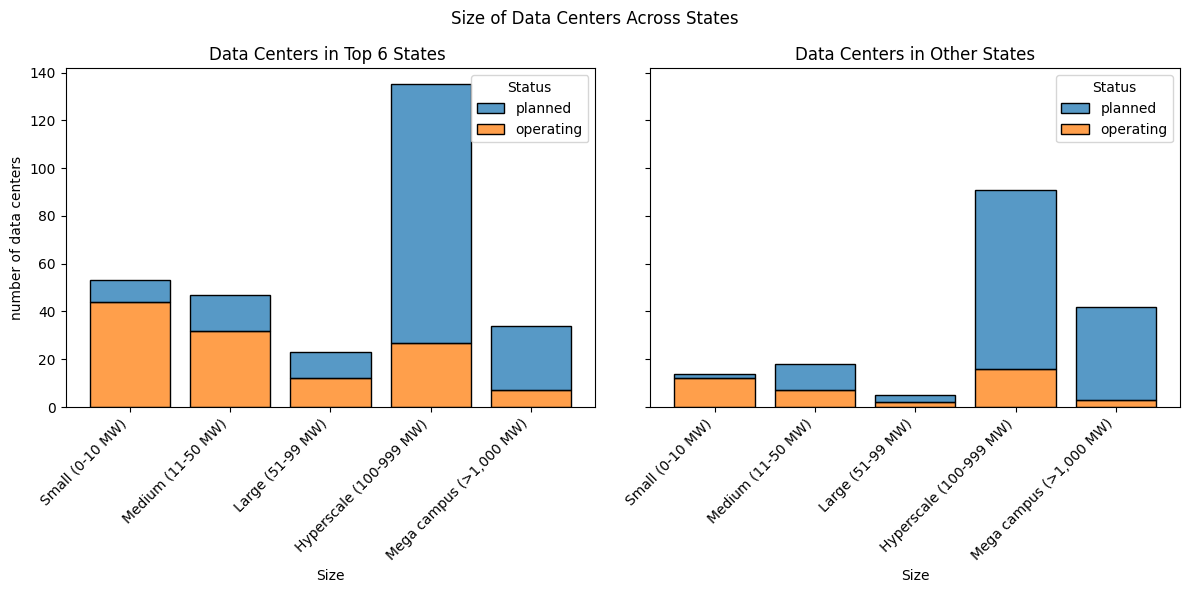

In [ ]:
top_states = ['VA', 'TX', 'GA', 'PA', 'OH', 'CA']

# Flag each row as top state or not (no duplication of rows)
datacenters_df['state_group'] = datacenters_df['state'].isin(top_states).map({True: 'Top', False: 'Other'})

#Filter to only operating and planned
datacenters_df = (
    datacenters_df[datacenters_df['status_group'].isin(['operating', 'planned'])]
    .copy()
)

#create new df that dropsna for operators and sizerank
datacenters_op_df = datacenters_df.dropna(subset=['operator_name', 'sizerank'])


chart_titles = {
    'Top': 'Data Centers in Top 6 States ',
    'Other': 'Data Centers in Other States'
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, group_name in zip(axes, ['Top', 'Other']):
    group_datacenters_df = datacenters_op_df[
        datacenters_op_df['state_group'] == group_name
    ]

    sns.histplot(
        data=group_datacenters_df,
        x='sizerank',
        hue='status_group',
        hue_order=['planned','operating'],
        multiple='stack',
        stat='count',
        shrink=0.8,
        ax=ax
    )

    ax.set_title(chart_titles[group_name])
    ax.set_xlabel('Size')
    ax.set_ylabel('number of data centers')
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

    ax.get_legend().set_title('Status')

fig.suptitle('Size of Data Centers Across States')
plt.tight_layout()
plt.show()


In [ ]:
#Top Datacenter Operators

operators = datacenters_op_df.dropna(subset = 'operator_name').groupby('operator_name').size()

operators.sort_values(ascending = False).head(10)


,0
operator_name,
Amazon,24
Microsoft,16
Meta,13
DataBank,12
Google,10
CyrusOne,10
Edged,9
Flexential,8
QTS Data Centers,8


In [ ]:
# Top operators ranked by number of facilities
top_operator_names = (
    datacenters_op_df['operator_name']
    .value_counts()
    .head(10)
    .index
)

# Number of distinct states per operator, split by state_group
operator_state_counts_df = (
    datacenters_op_df[datacenters_op_df['operator_name'].isin(top_operator_names)]
    .groupby(['operator_name', 'state_group'])['state']
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=top_operator_names, columns=['Top', 'Other'], fill_value=0)
)

operator_state_counts_df['total_dc'] = operator_state_counts_df['Top']+operator_state_counts_df['Other']

display(operator_state_counts_df.sort_values('total_dc', ascending = False))

state_group,Top,Other,total_dc
operator_name,,,
Amazon,6,6,12
Meta,3,7,10
Google,3,6,9
Microsoft,3,5,8
Edged,2,4,6
DataBank,3,2,5
CyrusOne,3,1,4
Flexential,3,1,4
QTS Data Centers,2,1,3


# ###Power Generator Analysis

1. Texas has exceedingly the most power generation compared to every other state. Texas has about 196,000 MW of operating capacity, nearly twice California’s (107,000 MW), and plans to add another 104,620 MW, a 53% increase.
Aditionally, Texas is the only top data center state where planned generation keeps pace with demand.
2. Virginia has the most data centers and the second-fastest electricity growth (+28.9%), yet it has the smallest grid of the six states (31,312 MW) and plans only 24% growth (7,618 MW).

In [ ]:
base = "https://raw.githubusercontent.com/nterreri-cmu/p2-datacenters/refs/heads/main/"

current = pd.read_csv(base + "EIA_Generator_Y2025_Current.csv")
proposed = pd.read_csv(base + "EIA_Generator_Y2025_Proposed.csv")

current.columns.tolist()

/tmp/ipykernel_30106/266940116.py:3: DtypeWarning: Columns (15,17,18,35,36,37,38,41,42,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  current = pd.read_csv(base + "EIA_Generator_Y2025_Current.csv")


['Utility ID',
 'Utility Name',
 'Plant Code',
 'Plant Name',
 'State',
 'County',
 'Generator ID',
 'Technology',
 'Prime Mover',
 'Unit Code',
 'Ownership',
 'Duct Burners',
 'Can Bypass Heat Recovery Steam Generator?',
 'RTO/ISO LMP Node Designation',
 'RTO/ISO Location Designation for Reporting Wholesale Sales Data to FERC',
 'Nameplate Capacity (MW)',
 'Nameplate Power Factor',
 'Summer Capacity (MW)',
 'Winter Capacity (MW)',
 'Minimum Load (MW)',
 'Uprate or Derate Completed During Year',
 'Month Uprate or Derate Completed',
 'Year Uprate or Derate Completed',
 'Status',
 'Synchronized to Transmission Grid',
 'Operating Month',
 'Operating Year',
 'Planned Retirement Month',
 'Planned Retirement Year',
 'Associated with Combined Heat and Power System',
 'Sector Name',
 'Sector',
 'Topping or Bottoming',
 'Energy Source 1',
 'Energy Source 2',
 'Energy Source 3',
 'Energy Source 4',
 'Energy Source 5',
 'Energy Source 6',
 'Startup Source 1',
 'Startup Source 2',
 'Startup Source

In [ ]:
print(current.shape, proposed.shape)
current.head()

(27918, 73) (2850, 47)


,Utility ID,Utility Name,Plant Code,Plant Name,State,County,Generator ID,Technology,Prime Mover,Unit Code,...,Planned Energy Source 1,Planned New Nameplate Capacity (MW),Planned Repower Month,Planned Repower Year,Other Planned Modifications?,Other Modifications Month,Other Modifications Year,Multiple Fuels?,Cofire Fuels?,Switch Between Oil and Natural Gas?
0,63560,"Sand Point Generating, LLC",1,Sand Point,AK,Aleutians East,1,Petroleum Liquids,IC,NaN,...,NaN,,,,NaN,,,N,NaN,NaN
1,63560,"Sand Point Generating, LLC",1,Sand Point,AK,Aleutians East,2,Petroleum Liquids,IC,NaN,...,NaN,,,,NaN,,,N,NaN,NaN
2,63560,"Sand Point Generating, LLC",1,Sand Point,AK,Aleutians East,3,Petroleum Liquids,IC,NaN,...,NaN,,,,NaN,,,N,NaN,NaN
3,63560,"Sand Point Generating, LLC",1,Sand Point,AK,Aleutians East,5.1,Petroleum Liquids,IC,NaN,...,NaN,,,,NaN,,,N,N,N
4,63560,"Sand Point Generating, LLC",1,Sand Point,AK,Aleutians East,WT1,Onshore Wind Turbine,WT,NaN,...,NaN,,,,NaN,,,NaN,NaN,NaN


In [ ]:
cap = "Nameplate Capacity (MW)"

In [ ]:

#converts capacity to numbers. labels each generator as Operating or Planned.
current[cap] = pd.to_numeric(current[cap].astype(str).str.replace(",", ""), errors="coerce")
proposed[cap] = pd.to_numeric(proposed[cap].astype(str).str.replace(",", ""), errors="coerce")

current["group"] = "Operating"
proposed["group"] = "Planned"

gens = pd.concat([current, proposed])

In [ ]:
#Capacity by state
state_cap = gens.pivot_table(index="State", columns="group", values=cap, aggfunc="sum").fillna(0)
state_cap["pct_growth"] = (state_cap["Planned"] / state_cap["Operating"] * 100).round(1)
state_cap = state_cap.round(0)
state_cap.sort_values("Operating", ascending=False).head(10)

group,Operating,Planned,pct_growth
State,,,
TX,195966.0,104620.0,53.0
CA,107433.0,22245.0,21.0
FL,79936.0,3649.0,5.0
PA,53097.0,6721.0,13.0
IL,52515.0,8897.0,17.0
NY,44194.0,7420.0,17.0
GA,42719.0,7901.0,18.0
AZ,40514.0,19868.0,49.0
NC,39933.0,2245.0,6.0


In [ ]:
#looking at top 6 data center states now
states6 = ["VA", "TX", "GA", "PA", "OH", "CA"]
top_six = state_cap.loc[states6]
top_six

group,Operating,Planned,pct_growth
State,,,
VA,31312.0,7618.0,24.0
TX,195966.0,104620.0,53.0
GA,42719.0,7901.0,18.0
PA,53097.0,6721.0,13.0
OH,34392.0,4939.0,14.0
CA,107433.0,22245.0,21.0


In [ ]:
current = pd.read_csv(base + "EIA_Generator_Y2025_Current.csv")
proposed = pd.read_csv(base + "EIA_Generator_Y2025_Proposed.csv")


/tmp/ipykernel_30106/1365864184.py:1: DtypeWarning: Columns (15,17,18,35,36,37,38,41,42,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  current = pd.read_csv(base + "EIA_Generator_Y2025_Current.csv")


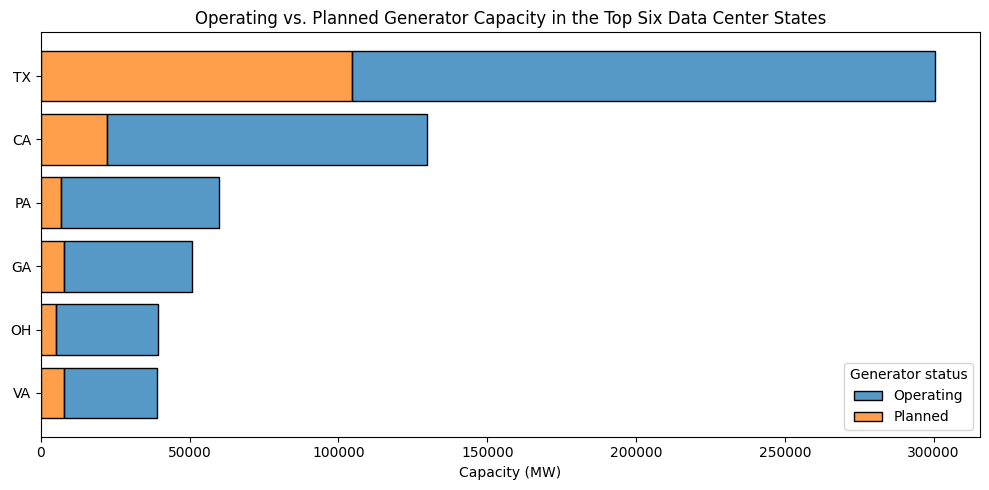

In [ ]:
legend_title = 'Generator status'

# Top six data center states
states6 = ['VA', 'TX', 'GA', 'PA', 'OH', 'CA']

# Reshape to long format: one row per state and status
plot_df = (
    state_cap.loc[states6, ['Operating', 'Planned']]
    .sort_values('Operating', ascending=False)
    .reset_index()
)
plot_df = plot_df.rename(columns={plot_df.columns[0]: 'state'})
plot_long_df = plot_df.melt(
    id_vars='state',
    value_vars=['Operating', 'Planned'],
    var_name='status',
    value_name='capacity_mw'
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=plot_long_df,
    y='state',
    weights='capacity_mw',
    hue='status',
    hue_order=['Operating', 'Planned'],
    multiple='stack',
    discrete=True,
    shrink=0.8,
    ax=ax
)

ax.set_title('Operating vs. Planned Generator Capacity in the Top Six Data Center States')
ax.set_xlabel('Capacity (MW)')
ax.set_ylabel('')
ax.get_legend().set_title(legend_title)

plt.tight_layout()
plt.savefig('generators_top6_dc_states.png', dpi=300, bbox_inches='tight')
plt.show()

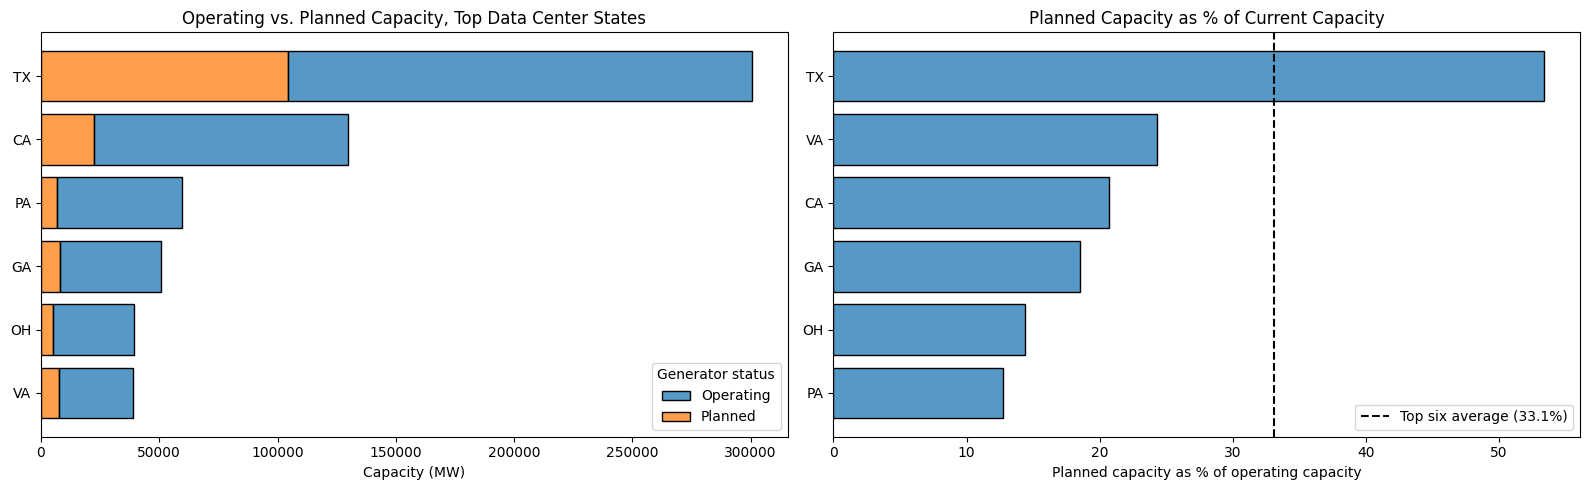

In [ ]:
legend_title = 'Generator status'

# top six Dc states generator capacity data
states6 = ['VA', 'TX', 'GA', 'PA', 'OH', 'CA']
top_six_cap = state_cap.loc[states6]

#cap six states and add percent growth
six_cap = top_six_cap.copy()
six_cap['pct_growth'] = (six_cap['Planned'] / six_cap['Operating'] * 100).round(1)

# Average across the top six data center states
top6_pct = (six_cap['Planned'].sum() / six_cap['Operating'].sum() * 100).round(1)

# Long format for the left panel
plot_df = (
    six_cap[['Operating', 'Planned']]
    .sort_values('Operating', ascending=False)
    .reset_index())
plot_df = plot_df.rename(columns={plot_df.columns[0]: 'state'})
plot_long_df = plot_df.melt(
    id_vars='state',
    value_vars=['Operating', 'Planned'],
    var_name='status',
    value_name='capacity_mw')

# Data for the right panel, largest growth at the top
pct_df = (
    six_cap['pct_growth']
    .sort_values(ascending=False)
    .reset_index())
pct_df = pct_df.rename(columns={pct_df.columns[0]: 'state'})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: operating vs. planned capacity
sns.histplot(
    data=plot_long_df,
    y='state',
    weights='capacity_mw',
    hue='status',
    hue_order=['Operating', 'Planned'],
    multiple='stack',
    discrete=True,
    shrink=0.8,
    ax=axes[0])
axes[0].set_title('Operating vs. Planned Capacity, Top Data Center States')   # <-- edit me
axes[0].set_xlabel('Capacity (MW)')
axes[0].set_ylabel('')
axes[0].get_legend().set_title(legend_title)

# Right: planned capacity as % of current capacity
sns.histplot(
    data=pct_df,
    y='state',
    weights='pct_growth',
    discrete=True,
    shrink=0.8,
    ax=axes[1])
axes[1].axvline(top6_pct, color='black', linestyle='--', label=f'Top six average ({top6_pct}%)')
axes[1].set_title('Planned Capacity as % of Current Capacity')   # <-- edit me
axes[1].set_xlabel('Planned capacity as % of operating capacity')
axes[1].set_ylabel('')
axes[1].legend()

plt.tight_layout()
plt.savefig('planned_capacity.png', dpi=300, bbox_inches='tight')
plt.show()

##Electricity Usage Analyses

#1. Electricity usage over time
Among the six states with the most data centers, electricity growth varied widely. Texas (+30.4%) and Virginia (+28.9%) grew nearly four times faster than the U.S. average (+7.9%) from 2016 to 2025. Georgia (+11%) also grew faster than the national average, while Ohio (+7.5%) was close to it. Pennsylvania (−1.4%) and California (−7.4%) used less electricity in 2025 than in 2016.

#2. Customer types
Commercial sales grew 19.2% in Georgia and 21.0% in Ohio, far faster than residential sales (+9.4% and +2.8%). In Virginia, commercial sales grew about 70%, the largest increase of any customer type in any of the six states. Texas was the exception: its largest growth was in industrial use (about 55%). California declined across all customer types, especially industrial (−18.0%).

In [ ]:
url = "https://raw.githubusercontent.com/nterreri-cmu/p2-datacenters/refs/heads/main/annual_electricity_usage_15-25.csv"
elec_df = pd.read_csv(url)


In [ ]:
#EDA
elec_df.shape
elec_df.head()
elec_df.info()
elec_df.isna().sum()
elec_df["period"].value_counts().sort_index()
elec_df["sectorName"].value_counts()
elec_df["stateid"].unique()
elec_df[["customers", "price", "revenue", "sales"]].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3720 entries, 0 to 3719
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   period            3720 non-null   int64  
 1   stateid           3720 non-null   object 
 2   stateDescription  3720 non-null   object 
 3   sectorid          3720 non-null   object 
 4   sectorName        3720 non-null   object 
 5   customers         3720 non-null   int64  
 6   price             3719 non-null   float64
 7   revenue           3719 non-null   float64
 8   sales             3719 non-null   float64
 9   customers-units   3720 non-null   object 
 10  price-units       3720 non-null   object 
 11  revenue-units     3720 non-null   object 
 12  sales-units       3720 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 377.9+ KB


,customers,price,revenue,sales
count,3.720000e+03,3719.000000,3719.000000,3.719000e+03
mean,2.543362e+06,9.184270,7171.579679,6.213635e+04
std,1.153051e+07,6.802483,28704.650507,2.433158e+05
min,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,1.000000e+00,5.850000,1.230720,1.281150e+01
50%,7.625600e+04,9.550000,1144.145700,1.144895e+04
75%,1.437632e+06,12.430000,4716.374350,4.390497e+04
max,1.662106e+08,43.030000,553284.834360,4.058007e+06


In [ ]:
#look at only states remove the national US total and any regional rows (
elec = elec_df[elec_df["stateid"] != "US"]
elec = elec[elec["stateid"].str.len() == 2]
elec["stateid"].nunique()

51

In [ ]:
#total US usage by year
total = elec[elec["sectorName"] == "all sectors"]

us_by_year = total.groupby("period")["sales"].sum()
us_by_year

,sales
period,
2016,3.762462e+06
2017,3.723356e+06
2018,3.859185e+06
2019,3.811150e+06
2020,3.717674e+06
2021,3.805874e+06
2022,3.927169e+06
2023,3.874253e+06
2024,3.975382e+06


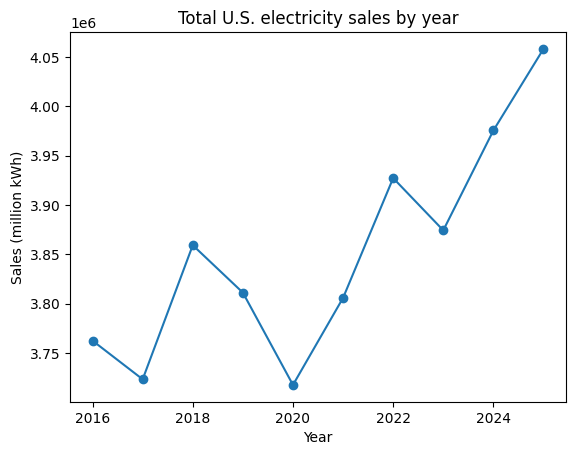

In [ ]:
us_by_year.plot(marker="o")
plt.title("Total U.S. electricity sales by year")
plt.xlabel("Year")
plt.ylabel("Sales (million kWh)")
plt.show()

U.S. growth: 7.9 %
stateid
TX    30.4
VA    28.9
GA    11.2
OH     7.5
PA    -1.4
CA    -7.4
dtype: float64


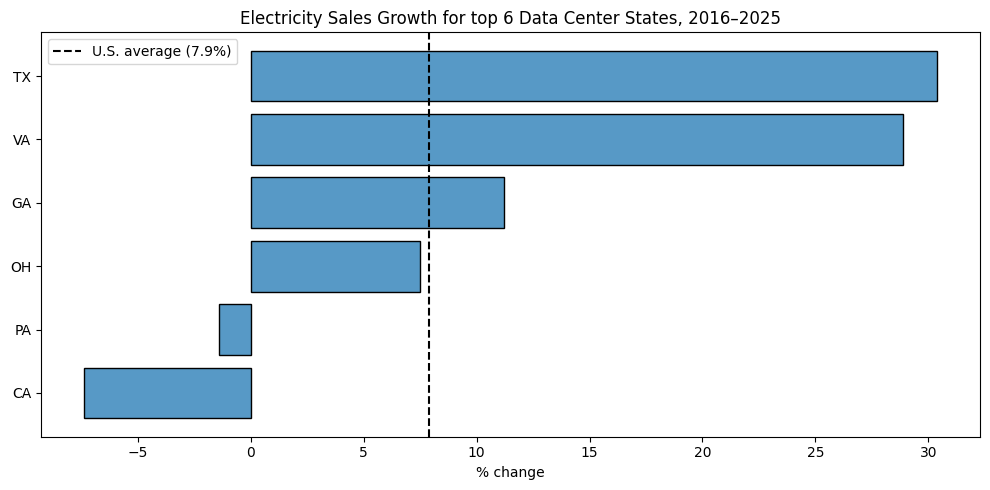

In [ ]:
# Looking at top data center states' electricity usage
# Define by_state using the 'total' dataframe
by_state = total.pivot(index="period", columns="stateid", values="sales")

# Pick the states
states6 = ["VA", "TX", "GA", "PA", "OH", "CA"]
top_six = by_state[states6]

# Growth from 2016 to 2025
six_growth = ((top_six.loc[2025] / top_six.loc[2016] - 1) * 100).round(1)
us_growth = ((us_by_year.loc[2025] / us_by_year.loc[2016] - 1) * 100).round(1)

print("U.S. growth:", us_growth, "%")
print(six_growth.sort_values(ascending=False))

# Chart
growth_df = six_growth.sort_values(ascending=False).reset_index()
growth_df.columns = ['state', 'pct_change']

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=growth_df,
    y='state',
    weights='pct_change',
    discrete=True,
    shrink=0.8,
    ax=ax
)

ax.axvline(us_growth, color='black', linestyle='--', label=f'U.S. average ({us_growth}%)')
ax.set_title('Electricity Sales Growth for top 6 Data Center States, 2016–2025')
ax.set_xlabel('% change')
ax.set_ylabel('')
ax.legend()

plt.tight_layout()
plt.savefig("six_states_growth.png", dpi=300, bbox_inches="tight")
plt.show()

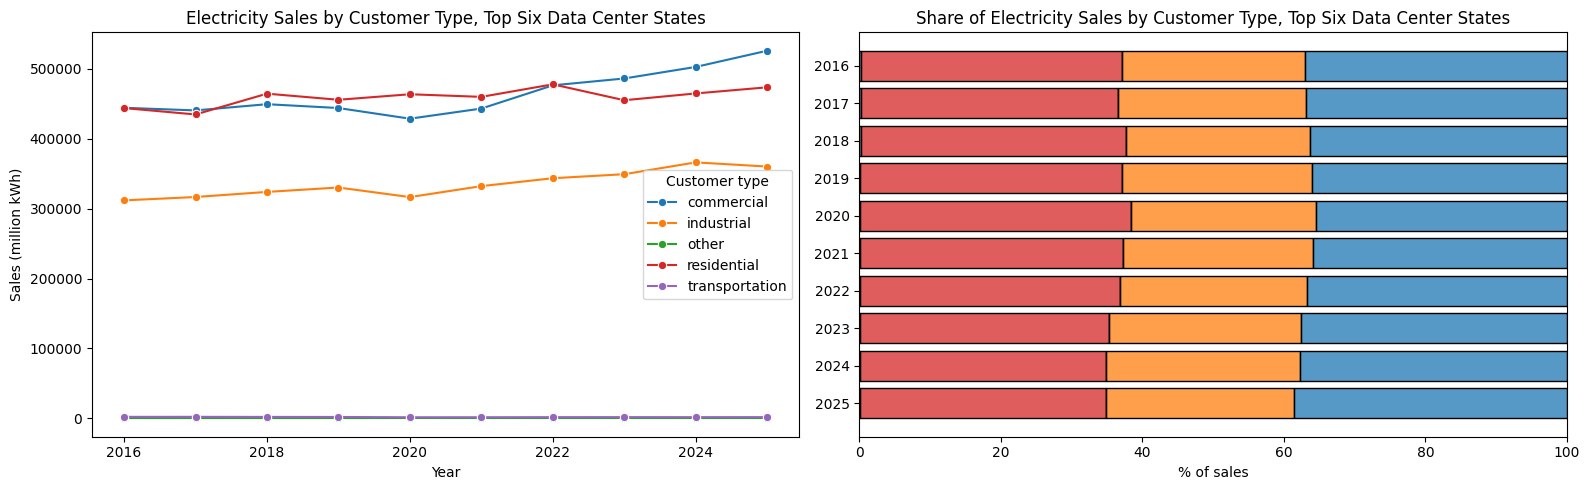

sectorName  commercial  industrial  other  residential  transportation
period                                                                
2016              37.0        25.9    0.0         36.9             0.2
2017              36.9        26.5    0.0         36.4             0.2
2018              36.2        26.1    0.0         37.5             0.2
2019              36.0        26.8    0.0         37.0             0.2
2020              35.4        26.2    0.0         38.3             0.1
2021              35.8        26.9    0.0         37.2             0.1
2022              36.7        26.4    0.0         36.8             0.1
2023              37.6        27.0    0.0         35.2             0.1
2024              37.6        27.4    0.0         34.8             0.1
2025              38.6        26.5    0.0         34.8             0.1


In [ ]:
states6 = ["VA", "TX", "GA", "PA", "OH", "CA"]

# Define types by filtering out 'all sectors' from the state-level data
types = elec[elec["sectorName"] != "all sectors"]

# Customer type sales for the 6 states
six_types = types[types["stateid"].isin(states6)]
six_type_by_year = six_types.pivot_table(index="period", columns="sectorName", values="sales", aggfunc="sum")
six_share = six_type_by_year.div(six_type_by_year.sum(axis=1), axis=0) * 100

legend_title = 'Customer type'
type_order = list(six_type_by_year.columns)

# Long format for seaborn
sales_long = six_type_by_year.reset_index().melt(
    id_vars='period', var_name='customer_type', value_name='sales'
)
share_long = six_share.reset_index().melt(
    id_vars='period', var_name='customer_type', value_name='share'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: sales by customer type
sns.lineplot(
    data=sales_long,
    x='period',
    y='sales',
    hue='customer_type',
    hue_order=type_order,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Electricity Sales by Customer Type, Top Six Data Center States')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Sales (million kWh)')
axes[0].get_legend().set_title(legend_title)

# Right: share by customer type
sns.histplot(
    data=share_long,
    y='period',
    weights='share',
    hue='customer_type',
    hue_order=type_order,
    multiple='stack',
    discrete=True,
    shrink=0.8,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Share of Electricity Sales by Customer Type, Top Six Data Center States')
axes[1].set_xlabel('% of sales')
axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)
axes[1].set_yticks(six_share.index)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("six_states_customer_type_side_by_side.png", dpi=300, bbox_inches="tight")
plt.show()

print(six_share.round(1))

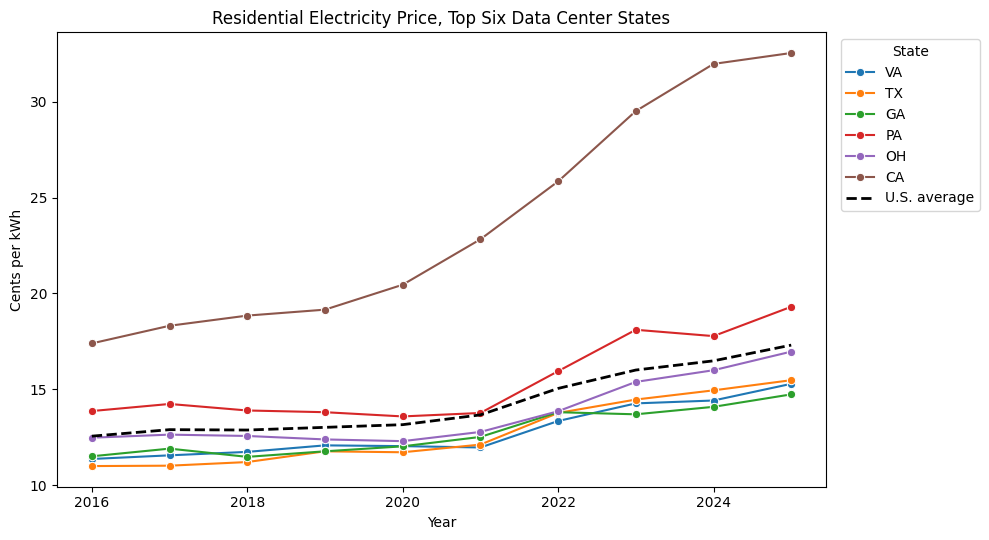

In [ ]:
states6 = ["VA", "TX", "GA", "PA", "OH", "CA"]

# Residential price for the 6 states
res = elec[elec["sectorName"] == "residential"]
six_price = res.pivot_table(index="period", columns="stateid", values="price")[states6]

# U.S. average residential price
us_res = elec_df[(elec_df["stateid"] == "US") & (elec_df["sectorName"] == "residential")]
us_price = us_res.set_index("period")["price"].sort_index()
legend_title = 'State'

# Long format for seaborn
price_long = six_price.reset_index().melt(
    id_vars='period', var_name='state', value_name='price'
)

# Chart
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.lineplot(
    data=price_long,
    x='period',
    y='price',
    hue='state',
    hue_order=states6,
    marker='o',
    ax=ax
)
ax.plot(us_price.index, us_price.values, color='black', linestyle='--', linewidth=2, label='U.S. average')

ax.set_title('Residential Electricity Price, Top Six Data Center States')   # <-- edit me
ax.set_xlabel('Year')
ax.set_ylabel('Cents per kWh')
ax.legend(title=legend_title, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig("residential_electricity_price.png", dpi=300, bbox_inches="tight")
plt.show()


U.S. price growth: 37.8 %
stateid
CA    87.1
TX    40.8
PA    39.2
OH    36.0
VA    34.5
GA    28.1
dtype: float64


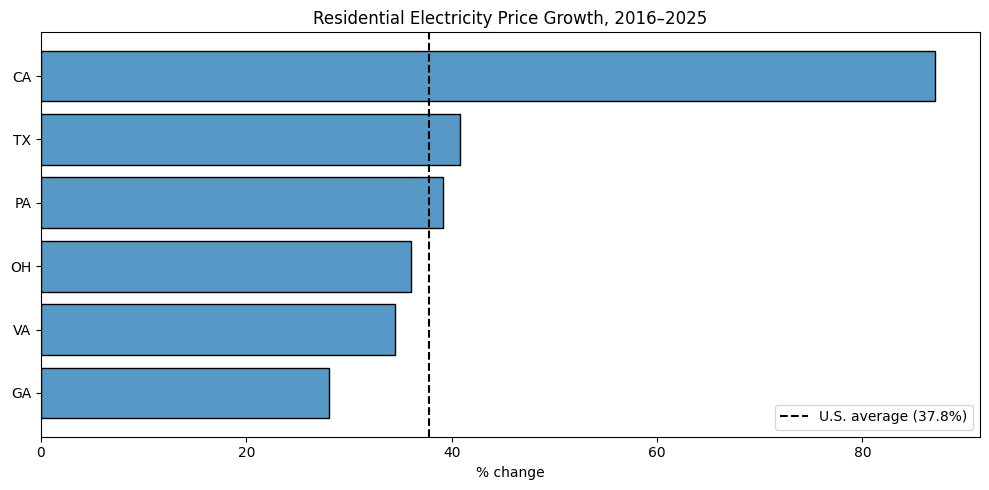

In [ ]:
# Residential price growth from 2016 to 2025
price_growth = ((six_price.loc[2025] / six_price.loc[2016] - 1) * 100).round(1)
us_price_growth = ((us_price.loc[2025] / us_price.loc[2016] - 1) * 100).round(1)

print("U.S. price growth:", us_price_growth, "%")
print(price_growth.sort_values(ascending=False))

# Chart
price_growth_df = price_growth.sort_values(ascending=False).reset_index()
price_growth_df.columns = ['state', 'pct_change']

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=price_growth_df,
    y='state',
    weights='pct_change',
    discrete=True,
    shrink=0.8,
    ax=ax
)

ax.axvline(us_price_growth, color='black', linestyle='--', label=f'U.S. average ({us_price_growth}%)')
ax.set_title('Residential Electricity Price Growth, 2016–2025')   # <-- edit me
ax.set_xlabel('% change')
ax.set_ylabel('')
ax.legend()

plt.tight_layout()
plt.savefig("six_states_price_growth.png", dpi=300, bbox_inches="tight")
plt.show()

###Analysis between Electricity Prices and Data Center Growth

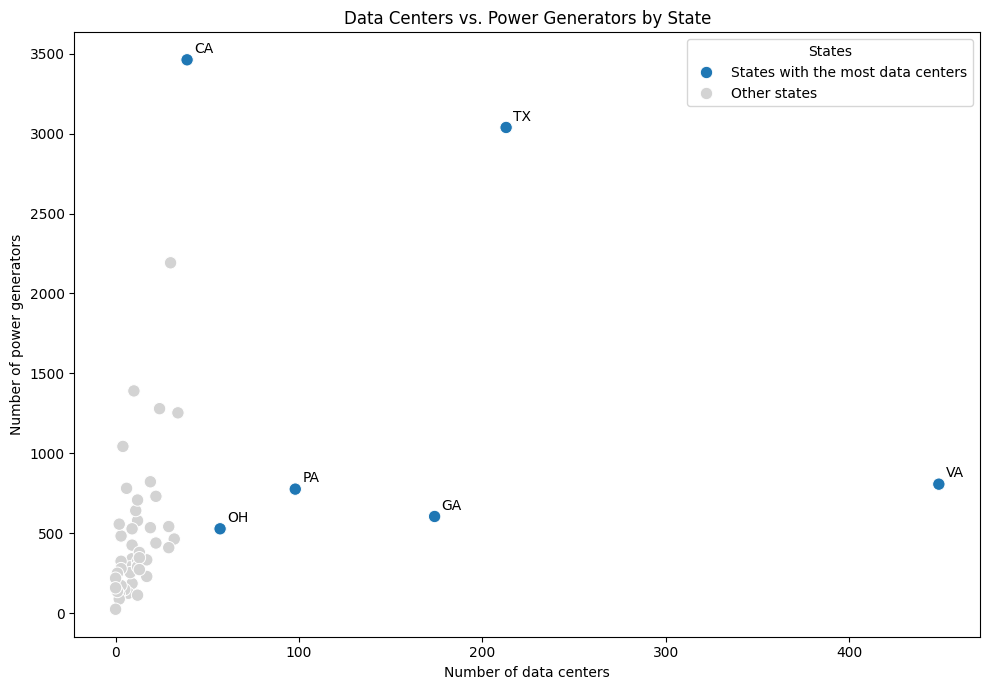

In [ ]:
legend_title = 'States'
states6 = ["VA", "TX", "GA", "PA", "OH", "CA"]

top_label = 'States with the most data centers'
other_label = 'Other states'

# One row per state: number of data centers and number of generators
dc_counts = datacenters_df['state'].value_counts().rename('data_centers')
gen_counts = gens['State'].value_counts().rename('generators')

scatter_df = pd.concat([dc_counts, gen_counts], axis=1).fillna(0).reset_index()
scatter_df = scatter_df.rename(columns={scatter_df.columns[0]: 'state'})

# Two groups: the top six states and all others
scatter_df['state_group'] = scatter_df['state'].isin(states6).map({True: top_label, False: other_label})

# Top six ilabled
palette = {top_label: sns.color_palette()[0], other_label: 'lightgray'}

fig, ax = plt.subplots(figsize=(10, 7))

# Plot other states first so the top six sit on top
sns.scatterplot(
    data=scatter_df.sort_values('state_group', key=lambda s: s == top_label),
    x='data_centers',
    y='generators',
    hue='state_group',
    hue_order=[top_label, other_label],
    palette=palette,
    s=80,
    ax=ax
)

# Label the top six states
for _, row in scatter_df[scatter_df['state'].isin(states6)].iterrows():
    ax.annotate(row['state'], (row['data_centers'], row['generators']),
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Data Centers vs. Power Generators by State')
ax.set_xlabel('Number of data centers')
ax.set_ylabel('Number of power generators')
ax.get_legend().set_title(legend_title)

plt.tight_layout()
plt.savefig("dc_vs_generators_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

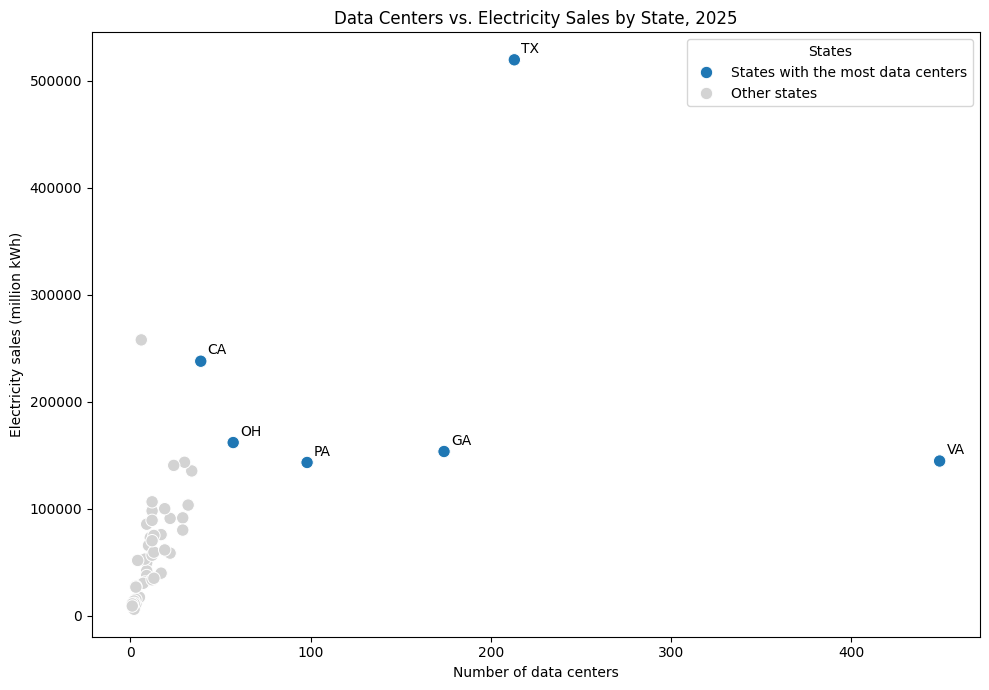

In [ ]:
legend_title = 'States'
states6 = ["VA", "TX", "GA", "PA", "OH", "CA"]

top_label = 'States with the most data centers'
other_label = 'Other states'

# One row per state: number of data centers and 2025 electricity sales
dc_counts = datacenters_df['state'].value_counts().rename('data_centers')
sales_2025 = by_state.loc[2025].rename('sales')

scatter_df = pd.concat([dc_counts, sales_2025], axis=1).dropna().reset_index()
scatter_df = scatter_df.rename(columns={scatter_df.columns[0]: 'state'})

# Two groups: the top six states and all others
scatter_df['state_group'] = scatter_df['state'].isin(states6).map({True: top_label, False: other_label})

# Top six labled
palette = {top_label: sns.color_palette()[0], other_label: 'lightgray'}

fig, ax = plt.subplots(figsize=(10, 7))

# Plot other states first
sns.scatterplot(
    data=scatter_df.sort_values('state_group', key=lambda s: s == top_label),
    x='data_centers',
    y='sales',
    hue='state_group',
    hue_order=[top_label, other_label],
    palette=palette,
    s=80,
    ax=ax
)

# Label the top six states
for _, row in scatter_df[scatter_df['state'].isin(states6)].iterrows():
    ax.annotate(row['state'], (row['data_centers'], row['sales']),
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Data Centers vs. Electricity Sales by State, 2025')   # <-- edit me
ax.set_xlabel('Number of data centers')
ax.set_ylabel('Electricity sales (million kWh)')
ax.get_legend().set_title(legend_title)

plt.tight_layout()
plt.savefig("dc_vs_electricity_sales_scatter.png", dpi=300, bbox_inches="tight")
plt.show()